In [8]:
# ── Imports + config ──────────────────────────────────────────────────────
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import matplotlib.pyplot as plt

_HERE = Path.cwd()
sys.path.insert(0, str(_HERE))                 # diagnostics.py
sys.path.insert(0, str(_HERE.parent))          # cass_analysis.py

from diagnostics import (
    build_couvreux_mask, updraft_mass_flux,
    entrainment_rate_tracer, entrainment_rate_siebesma,
)
from cass_analysis import (
    load_3d_nc, load_stats, RT_STYLE, RT_LABEL, LST_OFFSET, rho as RHO_REF,
)
from catalog import make_runset, CASS_ROOT

# ── experiment ─────────────────────────────────────────────────────────────
EXPT_KEY = 'no_aerosols_zero_wind_v2'
N_REPS   = 4
TAU      = 900.0          # tracer decay time scale (matches cass.ini)
SAVE_PDF = False

# Per-rep diagnostic results cached as netCDF on SCRATCH (regenerable, not in $HOME)
CACHE_DIR = CASS_ROOT / 'analysis' / 'cache' / 'h1_h2' / EXPT_KEY
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f'Cache dir: {CACHE_DIR}')


Cache dir: /pscratch/sd/m/mpowell/CASS_LES/analysis/cache/h1_h2/no_aerosols_zero_wind_v2


In [9]:
# ── Load + run diagnostics for every available rep ────────────────────────
rs = make_runset(EXPT_KEY, n_reps=N_REPS)


def _diag_for_rep(rep_dir: Path, rt: str) -> xr.Dataset:
    cache = CACHE_DIR / f'{rt}_{rep_dir.name}.nc'
    if cache.exists():
        ds = xr.open_dataset(cache).load()
        # Recompute if Siebesma–Cuijpers / Rio fields are missing (legacy cache)
        if 'eps_sc' in ds.variables and 'delta_sc' in ds.variables:
            return ds
        cache.unlink()
    ds_3d = load_3d_nc(rep_dir,
                        variables=['ql', 'w', 'couvreux'])
    stats = load_stats(rep_dir)
    masks = build_couvreux_mask(ds_3d, stats=stats)
    mf    = updraft_mass_flux(ds_3d, masks)
    ent_R = entrainment_rate_tracer(ds_3d, masks, stats, tau=TAU)   # Romps
    ent_S = entrainment_rate_siebesma(ds_3d, masks, mf, tau=TAU)    # Siebesma–Cuijpers / Rio
    out   = xr.merge([mf, ent_R, ent_S])
    out.to_netcdf(cache)
    return out


def _lst_from_da_time(time_da):
    """Return LST hours (float) given an xr time coord (datetime or float)."""
    vals = time_da.values
    if np.issubdtype(vals.dtype, np.datetime64):
        ti = pd.DatetimeIndex(vals)
        return ti.hour + ti.minute / 60.0 + ti.second / 3600.0
    # fallback: assume seconds-since-start
    return vals / 3600.0 + LST_OFFSET


diag = {}                                  # diag[rt] = {'reps': [Dataset, ...], 'mean':, 'std':}
for rt in ('2stream', 'raytracer'): # 
    rep_dirs = rs.dirs.get(rt, [])
    reps_ok = []
    for rd in rep_dirs:
        if not (rd / 'couvreux.nc').exists():
            print(f'  {rt}/{rd.name}: skip — no couvreux.nc (run 3d_to_nc.py first)')
            continue
        try:
            reps_ok.append(_diag_for_rep(rd, rt))
            print(f'  {rt}/{rd.name}: loaded ({reps_ok[-1].sizes["time"]} time steps)')
        except Exception as e:
            print(f'  {rt}/{rd.name}: ERROR  {e}')
    if not reps_ok:
        continue
    # Align to shortest time axis so ensemble mean is well-defined
    nt_min = min(d.sizes['time'] for d in reps_ok)
    aligned = [d.isel(time=slice(None, nt_min)) for d in reps_ok]
    # Strip datetime coord for stack; restore after
    t_coord = aligned[0]['time']
    prepped = [d.assign_coords(time=np.arange(nt_min)) for d in aligned]
    stacked = xr.concat(prepped, dim='rep')
    diag[rt] = {
        'reps':   aligned,
        'mean':   stacked.mean('rep').assign_coords(time=t_coord.values),
        'std':    stacked.std('rep', ddof=0).assign_coords(time=t_coord.values),
        'n_reps': len(reps_ok),
    }
    print(f'  → {rt} ensemble: n_reps={len(reps_ok)}, nt={nt_min}')

print(f'\nReady. RT types loaded: {list(diag.keys())}')


  2stream/rep_01: loaded (14 time steps)
  2stream/rep_02: loaded (14 time steps)
  2stream/rep_03: loaded (14 time steps)
  2stream/rep_04: loaded (14 time steps)
  → 2stream ensemble: n_reps=4, nt=14
  raytracer/rep_01: loaded (14 time steps)
  raytracer/rep_02: loaded (14 time steps)
  raytracer/rep_03: loaded (13 time steps)
  raytracer/rep_04: loaded (13 time steps)
  → raytracer ensemble: n_reps=4, nt=13

Ready. RT types loaded: ['2stream', 'raytracer']


### A3. Mass-flux decomposition Hovmöllers — M_up, a_up, w_up

Single 3 × 3 figure: rows are M_up / a_up / w_up; columns are 1D, 3D, (3D − 1D) / ⟨1D⟩ in percent. Each row uses its own colorbar; the two Δ%% columns share a row-wise colorbar (separate from absolute colorbar) so absolute and relative ranges are not conflated. All panels are subset to the cloudy period detected from 1D's M_up_cloudy_up.

Cloudy period:  LST 11.5–17.5 h (nt=7)
Refs ⟨1D⟩_cloudy_active:  M_up=0.1551  a_up=10.01%  w_up=1.72 m/s   (shared Δ%% vmax=21.4%)


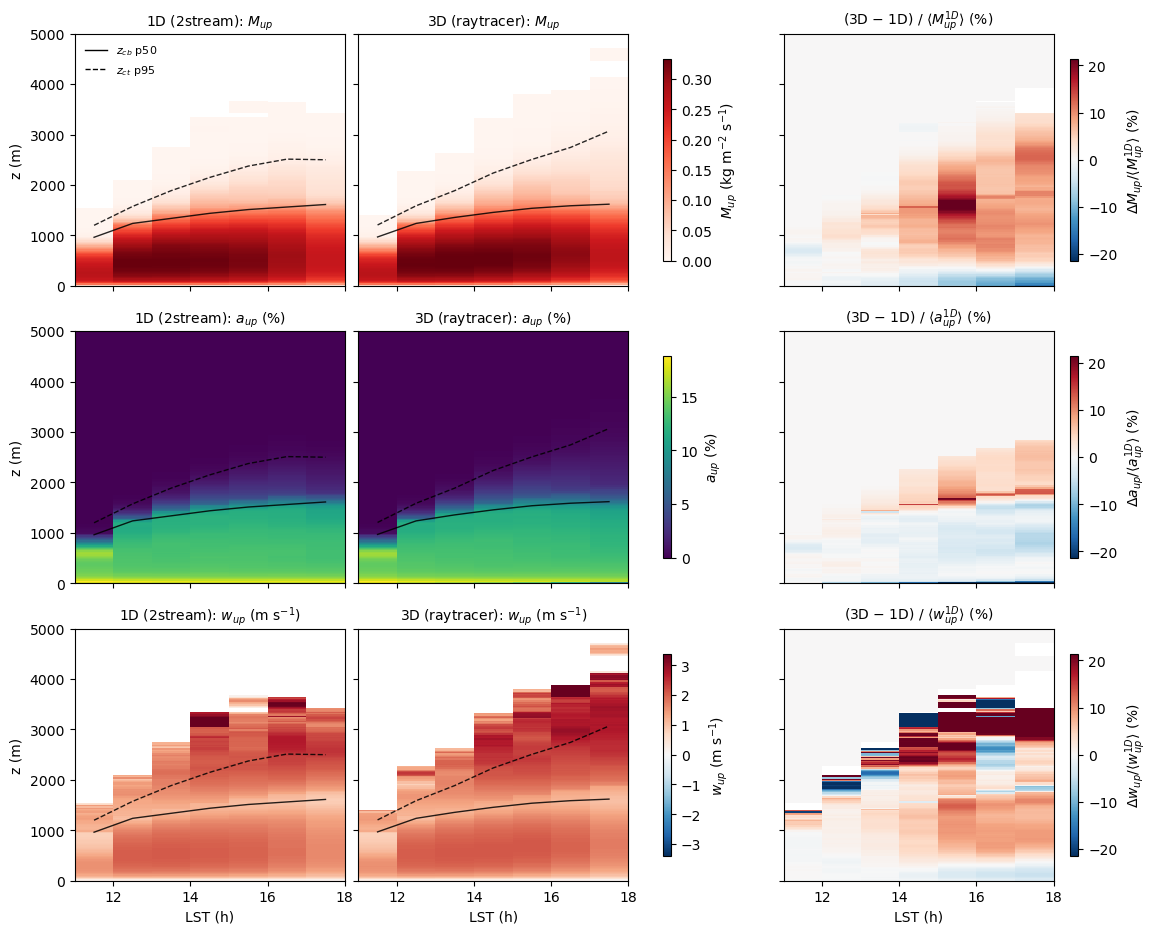

In [10]:
# ── Combined mass-flux Hovmöller: M_up, a_up, w_up × 1D, 3D, Δ% ─────────
# Subset to the cloudy period detected from 1D's M_up_cloudy_up.
# Δ% = (3D − 1D) / ⟨1D⟩_cloudy_active × 100, with a single scalar
# reference per quantity (computed over its own active region).
if not diag:
    print('No diagnostics loaded — nothing to plot.')
else:
    has_1d   = '2stream'   in diag
    has_3d   = 'raytracer' in diag
    has_diff = has_1d and has_3d
    rt_order = [rt for rt in ('2stream', 'raytracer') if rt in diag]

    nt_plot = min(diag[rt]['mean']['M_up_paper'].sizes['time']
                  for rt in rt_order)
    M_cu_1d = diag['2stream']['mean']['M_up_cloudy_up'].isel(
        time=slice(None, nt_plot))
    cloudy_t_mask = M_cu_1d.max('z').values > 1e-3
    if not cloudy_t_mask.any():
        ti_lo, ti_hi = 0, nt_plot
    else:
        ti_cloudy = np.where(cloudy_t_mask)[0]
        ti_lo, ti_hi = int(ti_cloudy[0]), int(ti_cloudy[-1]) + 1
    cloudy_slice = slice(ti_lo, ti_hi)

    M = {rt: diag[rt]['mean']['M_up_paper'].isel(time=cloudy_slice)
         for rt in rt_order}
    a = {rt: diag[rt]['mean']['a_up_paper'].isel(time=cloudy_slice)
         for rt in rt_order}
    w = {rt: diag[rt]['mean']['w_up_paper'].isel(time=cloudy_slice)
         for rt in rt_order}

    # ── Floors + scalar references for Δ% ───────────────────────────────
    M_FLOOR, A_FLOOR, W_FLOOR = 1e-3, 5e-3, 0.1   # kg m⁻² s⁻¹, 0.5 %, m/s
    M_ref = float(np.nanmean(
        M['2stream'].where(M['2stream'] > M_FLOOR).values)) if has_diff else None
    a_ref = float(np.nanmean(
        a['2stream'].where(a['2stream'] > A_FLOOR).values)) if has_diff else None
    w_ref = float(np.nanmean(
        w['2stream'].where(w['2stream'] > W_FLOOR).values)) if has_diff else None

    # ── Diff fields (% of scalar 1D reference) ──────────────────────────
    if has_diff:
        m_active = (M['raytracer'] > M_FLOOR) | (M['2stream'] > M_FLOOR)
        a_active = (a['raytracer'] > A_FLOOR) | (a['2stream'] > A_FLOOR)
        w_active = (w['raytracer'] > W_FLOOR) | (w['2stream'] > W_FLOOR)
        diff_M = xr.where(m_active,
                          (M['raytracer'] - M['2stream']) / M_ref * 100, 0.0)
        diff_a = xr.where(a_active,
                          (a['raytracer'] - a['2stream']) / a_ref * 100, 0.0)
        diff_w = xr.where(w_active,
                          (w['raytracer'] - w['2stream']) / w_ref * 100, 0.0)
        # Compute Δ% colorbar range from active-mask cells only — otherwise
        # the NaN→0 fill on inactive cells dilutes the percentile and shrinks
        # the colorbar.
        vmax_diff = float(np.nanpercentile(np.concatenate([
            np.abs(diff_M.values[m_active.values]).ravel(),
            np.abs(diff_a.values[a_active.values]).ravel(),
            np.abs(diff_w.values[w_active.values]).ravel(),
        ]), 95))
        lst_axis = _lst_from_da_time(M['2stream'].time)
        print(f'Cloudy period:  LST {lst_axis.min():.1f}–{lst_axis.max():.1f} h '
              f'(nt={ti_hi - ti_lo})')
        print(f'Refs ⟨1D⟩_cloudy_active:  M_up={M_ref:.4f}  a_up={a_ref*100:.2f}%  '
              f'w_up={w_ref:.2f} m/s   (shared Δ%% vmax={vmax_diff:.1f}%)')

    # ── Absolute color limits (per row) ─────────────────────────────────
    vmax_M = max(float(np.nanpercentile(np.abs(M[rt].values), 99))
                 for rt in rt_order)
    vmax_a = max(float(a[rt].max()) * 100 for rt in rt_order)        # %
    vmax_w = max(float(np.nanpercentile(np.abs(w[rt].values), 99))
                 for rt in rt_order)

    n_cols = len(rt_order) + (1 if has_diff else 0)
    fig, axes = plt.subplots(3, n_cols, figsize=(4.5 * n_cols, 11),
                              sharex=True, sharey=True,
                              gridspec_kw=dict(hspace=0.18, wspace=0.05))
    if axes.ndim == 1:
        axes = axes[:, np.newaxis]

    pcm_M_abs = pcm_a_abs = pcm_w_abs = None
    pcm_M_d = pcm_a_d = pcm_w_d = None

    # ── Row 0: M_up ─────────────────────────────────────────────────────
    for col, rt in enumerate(rt_order):
        t_lst = _lst_from_da_time(M[rt].time); z = M[rt].z.values
        pcm_M_abs = axes[0, col].pcolormesh(
            t_lst, z, M[rt].values.T, cmap='Reds',
            vmin=0, vmax=vmax_M, shading='auto')
        axes[0, col].set_title(f'{RT_LABEL[rt]}: $M_{{up}}$', fontsize=10)
    if has_diff:
        col = len(rt_order)
        t_lst = _lst_from_da_time(diff_M.time); z = diff_M.z.values
        pcm_M_d = axes[0, col].pcolormesh(
            t_lst, z, diff_M.values.T, cmap='RdBu_r',
            vmin=-vmax_diff, vmax=vmax_diff, shading='auto')
        axes[0, col].set_title(
            r'(3D − 1D) / $\langle M_{up}^{1D}\rangle$ (%)', fontsize=10)

    # ── Row 1: a_up ─────────────────────────────────────────────────────
    for col, rt in enumerate(rt_order):
        t_lst = _lst_from_da_time(a[rt].time); z = a[rt].z.values
        pcm_a_abs = axes[1, col].pcolormesh(
            t_lst, z, a[rt].values.T * 100, cmap='viridis',
            vmin=0, vmax=vmax_a, shading='auto')
        axes[1, col].set_title(f'{RT_LABEL[rt]}: $a_{{up}}$ (%)', fontsize=10)
    if has_diff:
        col = len(rt_order)
        t_lst = _lst_from_da_time(diff_a.time); z = diff_a.z.values
        pcm_a_d = axes[1, col].pcolormesh(
            t_lst, z, diff_a.values.T, cmap='RdBu_r',
            vmin=-vmax_diff, vmax=vmax_diff, shading='auto')
        axes[1, col].set_title(
            r'(3D − 1D) / $\langle a_{up}^{1D}\rangle$ (%)', fontsize=10)

    # ── Row 2: w_up ─────────────────────────────────────────────────────
    for col, rt in enumerate(rt_order):
        t_lst = _lst_from_da_time(w[rt].time); z = w[rt].z.values
        pcm_w_abs = axes[2, col].pcolormesh(
            t_lst, z, w[rt].values.T, cmap='RdBu_r',
            vmin=-vmax_w, vmax=vmax_w, shading='auto')
        axes[2, col].set_title(f'{RT_LABEL[rt]}: $w_{{up}}$ (m s$^{{-1}}$)',
                               fontsize=10)
    if has_diff:
        col = len(rt_order)
        t_lst = _lst_from_da_time(diff_w.time); z = diff_w.z.values
        pcm_w_d = axes[2, col].pcolormesh(
            t_lst, z, diff_w.values.T, cmap='RdBu_r',
            vmin=-vmax_diff, vmax=vmax_diff, shading='auto')
        axes[2, col].set_title(
            r'(3D − 1D) / $\langle w_{up}^{1D}\rangle$ (%)', fontsize=10)

    # ── Axis labels + per-row colorbars ─────────────────────────────────
    for ax in axes[-1, :]:
        ax.set_xlabel('LST (h)')
    for ax in axes[:, 0]:
        ax.set_ylabel('z (m)')

    fig.colorbar(pcm_M_abs, ax=list(axes[0, :len(rt_order)]),
                 shrink=0.8, aspect=25,
                 label=r'$M_{up}$ (kg m$^{-2}$ s$^{-1}$)')
    fig.colorbar(pcm_a_abs, ax=list(axes[1, :len(rt_order)]),
                 shrink=0.8, aspect=25, label=r'$a_{up}$ (%)')
    fig.colorbar(pcm_w_abs, ax=list(axes[2, :len(rt_order)]),
                 shrink=0.8, aspect=25, label=r'$w_{up}$ (m s$^{-1}$)')
    if has_diff:
        fig.colorbar(pcm_M_d, ax=axes[0, -1], shrink=0.8, aspect=25,
                     label=r'$\Delta M_{up}/\langle M_{up}^{1D}\rangle$ (%)')
        fig.colorbar(pcm_a_d, ax=axes[1, -1], shrink=0.8, aspect=25,
                     label=r'$\Delta a_{up}/\langle a_{up}^{1D}\rangle$ (%)')
        fig.colorbar(pcm_w_d, ax=axes[2, -1], shrink=0.8, aspect=25,
                     label=r'$\Delta w_{up}/\langle w_{up}^{1D}\rangle$ (%)')


    # ── Crop y-axis to cumulus layer (sharey=True propagates to all panels)
    axes[0, 0].set_ylim(0, 5000)

    # ── Overlay z_cb p50 and z_ct p50 / z_ct p95 from Couvreux per-column cache ────
    COL_CACHE = Path('/pscratch/sd/m/mpowell/CASS_LES/analysis/cache/couvreux_columns') / EXPT_KEY
    LST_OVR = np.arange(11.5, 18.51, 1.0); LST_HALF_OVR = 0.5

    def _ovr(rt):
        """Returns (z_cb p50, z_ct p95): cb at typical, ct at tail (overshoot)."""
        cb_runs = [[] for _ in LST_OVR]
        ct_runs = [[] for _ in LST_OVR]
        for f in sorted(COL_CACHE.glob(f'{rt}_rep_*.pkl')):
            with open(f, 'rb') as fh: d = pickle.load(fh)
            for j, lc in enumerate(LST_OVR):
                v_cb = d['z_cb']['values']; l_cb = d['z_cb']['lst']
                m_cb = np.abs(l_cb - lc) <= LST_HALF_OVR
                if m_cb.sum() >= 20:
                    cb_runs[j].append(np.percentile(v_cb[m_cb], 50))
                v_ct = d['z_ct']['values']; l_ct = d['z_ct']['lst']
                m_ct = np.abs(l_ct - lc) <= LST_HALF_OVR
                if m_ct.sum() >= 20:
                    ct_runs[j].append(np.percentile(v_ct[m_ct], 95))
        cb = np.array([np.mean(x) if x else np.nan for x in cb_runs])
        ct = np.array([np.mean(x) if x else np.nan for x in ct_runs])
        return cb, ct

    if COL_CACHE.exists():
        cb_ct = {rt: _ovr(rt) for rt in rt_order}
        for col, rt in enumerate(rt_order):
            for r in range(3):
                axes[r, col].plot(LST_OVR, cb_ct[rt][0], color='k', lw=1.0, ls='-',  alpha=0.85)
                axes[r, col].plot(LST_OVR, cb_ct[rt][1], color='k', lw=1.0, ls='--', alpha=0.85)
        # legend handle for cb / ct line styles, drop into top-left panel
        from matplotlib.lines import Line2D
        leg_h = [Line2D([0],[0], color='k', lw=1.0, ls='-',  label=r'$z_{cb}$ p50'),
                Line2D([0],[0], color='k', lw=1.0, ls='--', label=r'$z_{ct}$ p95')]
        axes[0, 0].legend(handles=leg_h, fontsize=8, frameon=False, loc='upper left')

    if SAVE_PDF:
        plt.savefig('h1_M_aw_combined.pdf', bbox_inches='tight')
    plt.show()


### B. Cross-section snapshot — clouds, tracer anomaly, surface SW (LST 17:30)

Single-snapshot cross-section through the LWP-largest cloud per RT. Top
row uses the full domain; bottom row zooms to the cloud-centred window
highlighted in orange. Clouds (q_l > 1e-5) shaded gray; black contours
are the standardized Couvreux tracer anomaly (σ-units). The line plot
under each cross-section is surface SW↓ along the same y-line — under-
cloud SW shadows are visible directly. The dashed horizontal reference
on each SW panel is SW_clr (99th percentile of the 1D field).

Slice files are pre-built from raw 3D dumps via
`slice_prep/build_xsection.sh <DUMP_TIME_S>`.

/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


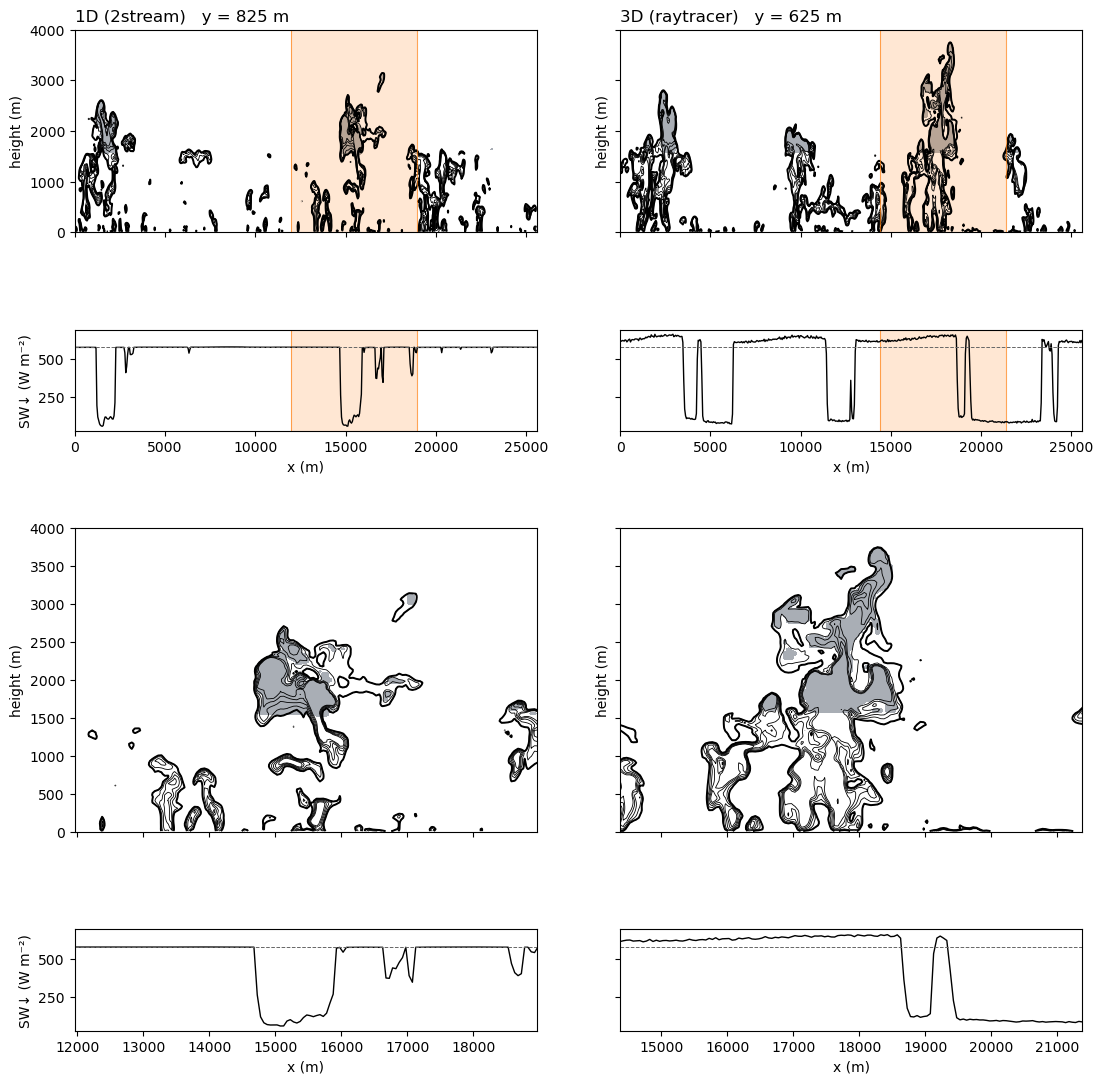

In [11]:
# ── B. Cross-section figure (single snapshot) ─────────────────────────────
import netCDF4 as nc
from matplotlib import gridspec
from scipy import ndimage

DUMP_TIME = 43200            # LST 17:30
REP_FOR_XSEC = 'rep_01'
QL_TH_X   = 1e-5
SIGMA_LV  = [1.0, 1.5, 2.0, 2.5, 3.0]
Z_MAX_X   = 4000.0
FULL_X    = (0.0, 25600.0)
SLICE_DIR = (CASS_ROOT / 'analysis' / 'mechanism_slices'
             / f'{EXPT_KEY}_{REP_FOR_XSEC}_t{DUMP_TIME}')

def _load_xz(path, var, y0):
    with nc.Dataset(path) as ds:
        x  = ds.variables['x'][:].astype(np.float32)
        y  = ds.variables['y'][:].astype(np.float32)
        z  = ds.variables['z'][:].astype(np.float32)
        j  = int(np.argmin(np.abs(y - y0)))
        d  = ds.variables[var][:, j, :].astype(np.float32)
    return x, z, d, float(y[j])

def _load_sw_line(path, y0):
    with nc.Dataset(path) as ds:
        x  = ds.variables['x'][:].astype(np.float32)
        y  = ds.variables['y'][:].astype(np.float32)
        j  = int(np.argmin(np.abs(y - y0)))
        sw = ds.variables['sw_total'][j, :].astype(np.float32)
    return x, sw, float(y[j])

def _largest_cloud(ql_path, ql_th):
    """LWP-weighted centroid + x-span of biggest connected cloud."""
    with nc.Dataset(ql_path) as ds:
        x  = ds.variables['x'][:].astype(np.float32)
        y  = ds.variables['y'][:].astype(np.float32)
        ql = ds.variables['ql'][:]
        z  = ds.variables['z'][:].astype(np.float32)
    dz = float(np.median(np.diff(z))) if z.size > 1 else 25.0
    cloudy = ql > ql_th
    lwp = (ql * cloudy).sum(axis=0) * dz
    labels, n = ndimage.label(cloudy.any(axis=0))
    masses = ndimage.sum(lwp, labels, index=range(1, n + 1))
    big = int(np.argmax(masses)) + 1
    yi, xi = np.where(labels == big)
    w = lwp[yi, xi]
    return (float(np.average(x[xi], weights=w)),
            float(np.average(y[yi], weights=w)),
            float(x[int(xi.min())]), float(x[int(xi.max())]))

def _draw_cross(ax, rt, y0, xr_):
    qx, qz, ql, ya = _load_xz(SLICE_DIR / f'ql_{rt}.nc',       'ql',       y0)
    cx_, cz, cu, _ = _load_xz(SLICE_DIR / f'couvreux_{rt}.nc', 'couvreux', y0)
    Xc, Zc = np.meshgrid(qx, qz)
    if (ql > QL_TH_X).any():
        ax.contourf(Xc, Zc, (ql > QL_TH_X).astype(np.float32),
                    levels=[0.5, 1.5], colors=['#9aa0a8'], alpha=0.85)
    ax.contour(Xc, Zc, cu, levels=SIGMA_LV, colors='k', linewidths=0.6)
    ax.contour(Xc, Zc, cu, levels=[1.0],   colors='k', linewidths=1.4)
    ax.set_xlim(*xr_); ax.set_ylim(0, Z_MAX_X); ax.set_ylabel('height (m)')
    ax.set_title(f'{RT_LABEL[rt]}   y = {ya:.0f} m', loc='left')
    return ya

# Pick cross-section line per RT from the largest cloud, then use a
# common half-width so both panels render at the same physical scale.
meta = {}
for rt in ('2stream', 'raytracer'):
    cx, cy, x0, x1 = _largest_cloud(SLICE_DIR / f'ql_{rt}.nc', QL_TH_X)
    meta[rt] = dict(cx=cx, y0=cy, half=max(3500.0, (x1 - x0) * 0.6))
common_half = max(meta[rt]['half'] for rt in meta)
for rt in meta:
    cx = meta[rt]['cx']
    meta[rt]['zoom'] = (max(0.0, cx - common_half), cx + common_half)

fig = plt.figure(figsize=(13, 13))
gs  = gridspec.GridSpec(4, 2, figure=fig,
                        height_ratios=[2, 1, 3, 1],
                        hspace=0.55, wspace=0.18)
ax_full_1d = fig.add_subplot(gs[0, 0])
ax_full_3d = fig.add_subplot(gs[0, 1], sharey=ax_full_1d)
ax_full_sw_1d = fig.add_subplot(gs[1, 0], sharex=ax_full_1d)
ax_full_sw_3d = fig.add_subplot(gs[1, 1], sharex=ax_full_3d,
                                sharey=ax_full_sw_1d)
ax_zoom_1d = fig.add_subplot(gs[2, 0])
ax_zoom_3d = fig.add_subplot(gs[2, 1], sharey=ax_zoom_1d)
ax_sw_1d   = fig.add_subplot(gs[3, 0], sharex=ax_zoom_1d)
ax_sw_3d   = fig.add_subplot(gs[3, 1], sharex=ax_zoom_3d,
                             sharey=ax_sw_1d)

# Full-x cross-section
_draw_cross(ax_full_1d, '2stream',   meta['2stream']['y0'],   FULL_X)
_draw_cross(ax_full_3d, 'raytracer', meta['raytracer']['y0'], FULL_X)
plt.setp(ax_full_1d.get_xticklabels(), visible=False)
plt.setp(ax_full_3d.get_xticklabels(), visible=False)
plt.setp(ax_full_3d.get_yticklabels(), visible=False)

# Highlight zoom region on each full-x panel + matching SW line
for ax_xs, ax_sw, rt in (
    (ax_full_1d, ax_full_sw_1d, '2stream'),
    (ax_full_3d, ax_full_sw_3d, 'raytracer'),
):
    zlo, zhi = meta[rt]['zoom']
    for a in (ax_xs, ax_sw):
        a.axvspan(zlo, zhi, alpha=0.18, color='tab:orange', linewidth=0.0)
        a.axvline(zlo, color='tab:orange', lw=0.8, alpha=0.7)
        a.axvline(zhi, color='tab:orange', lw=0.8, alpha=0.7)

# Full-x SW
sw_x_1d, sw_full_1d, _ = _load_sw_line(
    SLICE_DIR / 'sw_2stream.nc',   meta['2stream']['y0'])
sw_x_3d, sw_full_3d, _ = _load_sw_line(
    SLICE_DIR / 'sw_raytracer.nc', meta['raytracer']['y0'])
ax_full_sw_1d.plot(sw_x_1d, sw_full_1d, lw=1.0, color='k')
ax_full_sw_3d.plot(sw_x_3d, sw_full_3d, lw=1.0, color='k')
for a in (ax_full_sw_1d, ax_full_sw_3d):
    a.set_xlim(*FULL_X); a.set_xlabel('x (m)')
ax_full_sw_1d.set_ylabel('SW↓ (W m⁻²)')
plt.setp(ax_full_sw_3d.get_yticklabels(), visible=False)

# Zoom cross-section + zoom SW
for ax_xs, ax_sw, rt in (
    (ax_zoom_1d, ax_sw_1d, '2stream'),
    (ax_zoom_3d, ax_sw_3d, 'raytracer'),
):
    _draw_cross(ax_xs, rt, meta[rt]['y0'], meta[rt]['zoom'])
    ax_xs.set_title('', loc='left')
    plt.setp(ax_xs.get_xticklabels(), visible=False)
    sw_x, sw, _ = _load_sw_line(SLICE_DIR / f'sw_{rt}.nc', meta[rt]['y0'])
    ax_sw.plot(sw_x, sw, lw=1.0, color='k')
    ax_sw.set_xlim(*meta[rt]['zoom']); ax_sw.set_xlabel('x (m)')
ax_sw_1d.set_ylabel('SW↓ (W m⁻²)')
plt.setp(ax_zoom_3d.get_yticklabels(), visible=False)
plt.setp(ax_sw_3d.get_yticklabels(), visible=False)

# SW_clr reference (99th pct of full 1D field) on every SW panel
sw_clr = float(np.percentile(sw_full_1d, 99))
for ax in (ax_full_sw_1d, ax_full_sw_3d, ax_sw_1d, ax_sw_3d):
    ax.axhline(sw_clr, ls='--', lw=0.7, color='0.4')

plt.show()


### D. ε(ẑ) and δ(ẑ) profiles — Gentine, afternoon only

ε and δ from the Gentine plume diagnostic (`compute_entrainment.py`,
v1 entrainment cache), binned in normalised in-cloud height
ẑ = (z − z_cb) / (z_ct − z_cb), M-weighted within each bin.
Restricted to plumes with LST ∈ [14, 17] (latest hours in current cache).
1D solid, 3D dashed; ±1 SEM across reps shaded.


/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3670: UserWarning: PLUME_ROOT_4P: no v2 entrainment data at /pscratch/sd/m/mpowell/CASS_LES/analysis/entrainment/no_aerosols_zero_wind_v2; falling back to v1 (/pscratch/sd/m/mpowell/CASS_LES/analysis/entrainment/no_aerosols_zero_wind). Plume-4P results below are computed against v1 dynamics and may not be consistent with the rest of this notebook (v2). Regenerate v2 entrainment to fix.
  exec(code_obj, self.user_global_ns, self.user_ns)


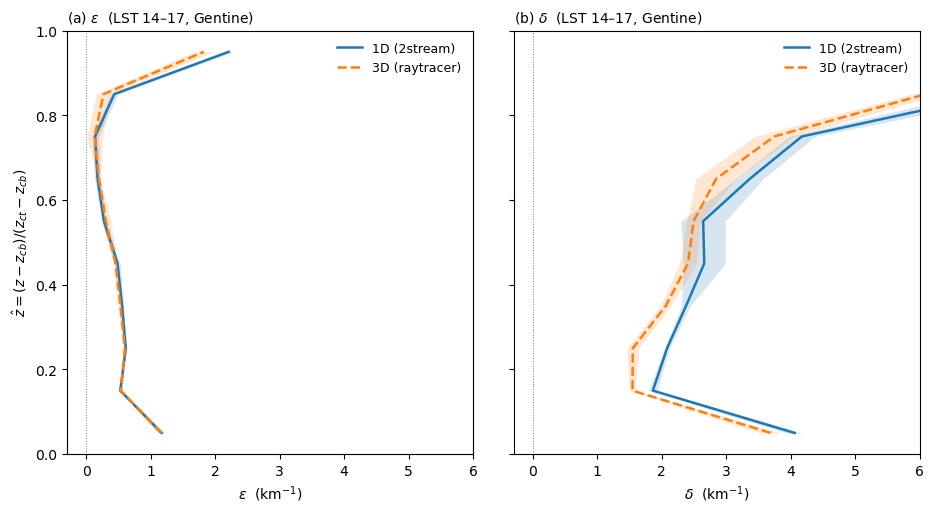

In [12]:
# ── D. ε(ẑ) + δ(ẑ) absolute profiles — Gentine plume diagnostic, afternoon ─
# 1×2 layout: (a) ε absolute, (b) δ absolute. 1D solid, 3D dashed.
# Filter to afternoon plumes (LST 14–17, or whatever is latest in the cache).
# plume-4P entrainment data — was computed on v1 dynamics; not yet rebuilt on v2.
PLUME_ROOT_4P = CASS_ROOT / 'analysis' / 'entrainment' / EXPT_KEY
if not PLUME_ROOT_4P.exists():
    # Fall back to the v1 dataset with a loud warning so callers know
    # the plume-4P section is using stale (v1-derived) data.
    _fallback = CASS_ROOT / 'analysis' / 'entrainment' / 'no_aerosols_zero_wind'
    if _fallback.exists():
        import warnings
        warnings.warn(
            f'PLUME_ROOT_4P: no v2 entrainment data at {PLUME_ROOT_4P}; '
            f'falling back to v1 ({_fallback}). Plume-4P results below are '
            f'computed against v1 dynamics and may not be consistent with the '
            f'rest of this notebook (v2). Regenerate v2 entrainment to fix.',
            stacklevel=2)
        PLUME_ROOT_4P = _fallback
    else:
        raise FileNotFoundError(
            f'No plume-4P entrainment data at {PLUME_ROOT_4P} (and no v1 '
            f'fallback). Regenerate before running this section.')
RT_COLOR      = {'2stream': 'tab:blue', 'raytracer': 'tab:orange'}
LST_LO, LST_HI = 14.0, 17.0
Z_ND_EDGES = np.linspace(0.0, 1.0, 11)
Z_ND_CENT  = 0.5 * (Z_ND_EDGES[:-1] + Z_ND_EDGES[1:])
ABS_XLIM   = 6.0   # km^-1


def _plume_znd_afternoon(rt, n_reps, lst_lo=LST_LO, lst_hi=LST_HI):
    """Gentine plume-method ε, δ binned in ẑ, M-weighted, afternoon plumes only."""
    out = {'epsilon': [], 'delta': []}
    for i in range(1, n_reps + 1):
        f = PLUME_ROOT_4P / rt / f'rep_{i:02d}' / 'entrainment.nc'
        if not f.exists(): continue
        with xr.open_dataset(f) as ds:
            pid  = ds['plume_id'].values
            plst = ds['plume_lst'].values
            aft  = (plst[pid] >= lst_lo) & (plst[pid] <= lst_hi)
            cb   = ds['plume_cb_z'].values[pid]
            ct   = ds['plume_ct_z'].values[pid]
            depth = np.where(ct - cb > 100.0, ct - cb, np.nan)
            z_nd = (ds['z'].values - cb) / depth
            M    = ds['M'].values
            w    = np.where(np.isfinite(M) & (M > 0) & aft, M, 0.0)
            for key in ('epsilon', 'delta'):
                y = ds[key].values
                m = np.full(len(Z_ND_CENT), np.nan)
                for j in range(len(Z_ND_CENT)):
                    sel = (z_nd >= Z_ND_EDGES[j]) & (z_nd < Z_ND_EDGES[j + 1])
                    sel &= np.isfinite(y) & (w > 0)
                    if sel.sum() < 20: continue
                    m[j] = np.sum(w[sel] * y[sel]) / np.sum(w[sel])
                out[key].append(m)
    return {k: (np.stack(v) * 1e3 if v else np.empty((0, len(Z_ND_CENT))))
            for k, v in out.items()}


PG = {rt: _plume_znd_afternoon(rt, N_REPS) for rt in ('2stream', 'raytracer')}


def _abs_panel(ax, key):
    for rt, ls in (('2stream', '-'), ('raytracer', '--')):
        arr = PG[rt][key]
        if arr.size == 0: continue
        m = np.nanmean(arr, axis=0)
        n_eff = np.maximum(np.sum(np.isfinite(arr), axis=0), 1)
        sem = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(n_eff)
        ok = np.isfinite(m)
        ax.plot(m[ok], Z_ND_CENT[ok], color=RT_COLOR[rt], lw=1.8, ls=ls,
                label=f'{RT_LABEL[rt]}')
        ax.fill_betweenx(Z_ND_CENT[ok],
                         (m - sem)[ok], (m + sem)[ok],
                         color=RT_COLOR[rt], alpha=0.18, linewidth=0)
    ax.axvline(0, color='0.5', lw=0.7, ls=':')
    ax.set_xlim(-ABS_XLIM * 0.05, ABS_XLIM); ax.set_ylim(0, 1)


fig, (ax_e, ax_d) = plt.subplots(1, 2, figsize=(11, 5.5),
                                 sharey=True,
                                 gridspec_kw=dict(wspace=0.10))
_abs_panel(ax_e, 'epsilon')
_abs_panel(ax_d, 'delta')
ax_e.set_xlabel(r'$\varepsilon$  (km$^{-1}$)')
ax_d.set_xlabel(r'$\delta$  (km$^{-1}$)')
ax_e.set_ylabel(r'$\hat z = (z - z_{cb}) / (z_{ct} - z_{cb})$')
ax_e.set_title(rf'(a) $\varepsilon$  (LST {LST_LO:.0f}–{LST_HI:.0f}, Gentine)',
               loc='left', fontsize=10)
ax_d.set_title(rf'(b) $\delta$  (LST {LST_LO:.0f}–{LST_HI:.0f}, Gentine)',
               loc='left', fontsize=10)
ax_e.legend(fontsize=9, frameon=False, loc='upper right')
ax_d.legend(fontsize=9, frameon=False, loc='upper right')
plt.show()


### E. Horizontal autocorrelation of the updraft indicator — coherence length L(z)

At each (z, t) compute the doubly periodic 2D autocorrelation of the
Couvreux paper mask via FFT, radially average, then derive an integral
length scale  $L(z) = \int_0^{r_0} C(r)\,dr$  where $r_0$ is the first
zero crossing. LES is doubly periodic so the FFT autocorrelation is
exact (no edge bias).

Restricted to afternoon plumes (LST 14–17, matching panel D);
ensemble-averaged over reps. The right two panels show the mean radial
autocorrelation $C(r, z)$. If 3D RT organizes the BL into fewer,
larger coherent plumes, $L(z)$ should grow with height through the
subcloud and grow faster in 3D than in 1D.

In [13]:
# ── E. Autocorrelation diagnostic — compute + cache per rep ──────────────
from numpy.fft import fft2, ifft2, fftshift

LST_LO_E, LST_HI_E = 14.0, 17.0
N_BINS_E           = 64

AC_CACHE = CASS_ROOT / 'analysis' / 'cache' / 'autocorr' / EXPT_KEY
AC_CACHE.mkdir(parents=True, exist_ok=True)
print(f'AC cache dir: {AC_CACHE}')


def _autocorr_radial(mask: xr.DataArray, n_bins: int = N_BINS_E) -> xr.Dataset:
    """Doubly periodic 2D autocorrelation C(r, z, t), radially averaged.

    C(r, z, t) = <m'(x, y) · m'(x+rx, y+ry)>_{xy} / Var(m')   ,
    where m' = mask − ⟨mask⟩_{xy}. FFT exploits the periodic BC, so
    every lag is unbiased.  C(r=0)=1; for a zero-mean field ∑C·dA → 0.
    """
    nt = mask.sizes['time']; nz = mask.sizes['z']
    ny = mask.sizes['y'];    nx = mask.sizes['x']
    dx = float(np.median(np.diff(mask.x.values)))
    dy = float(np.median(np.diff(mask.y.values)))

    rx = (np.arange(nx) - nx // 2) * dx
    ry = (np.arange(ny) - ny // 2) * dy
    Rx, Ry = np.meshgrid(rx, ry)
    rgrid = np.hypot(Rx, Ry).ravel()
    r_max = min(nx * dx, ny * dy) / 2
    edges   = np.linspace(0.0, r_max, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_idx = np.clip(np.digitize(rgrid, edges) - 1, 0, n_bins - 1)
    counts  = np.bincount(bin_idx, minlength=n_bins).astype(np.float64)

    out = np.full((nt, nz, n_bins), np.nan, dtype=np.float32)
    for it in range(nt):
        m = mask.isel(time=it).transpose('z', 'y', 'x').values.astype(np.float32)
        mp  = m - m.mean(axis=(-2, -1), keepdims=True)
        var = mp.var(axis=(-2, -1))                            # (z,)
        F   = fft2(mp, axes=(-2, -1))
        R   = np.real(ifft2(F * np.conj(F), axes=(-2, -1))) / (ny * nx)
        Cs  = fftshift(R, axes=(-2, -1)).reshape(nz, -1)       # (z, ny*nx)
        for iz in range(nz):
            if var[iz] <= 0: continue
            s = np.bincount(bin_idx, weights=Cs[iz], minlength=n_bins)
            out[it, iz] = (s / counts) / var[iz]
    return xr.Dataset(
        {'C': (('time', 'z', 'r'), out)},
        coords={'time': mask.time, 'z': mask.z, 'r': centers},
    )


def _autocorr_for_rep(rep_dir: Path, rt: str) -> xr.Dataset:
    cache = AC_CACHE / f'{rt}_{rep_dir.name}.nc'
    if cache.exists():
        return xr.open_dataset(cache).load()
    ds_3d = load_3d_nc(rep_dir, variables=['ql', 'w', 'couvreux'])
    stats = load_stats(rep_dir)
    masks = build_couvreux_mask(ds_3d, stats=stats)
    ds_ac = _autocorr_radial(masks['mask_paper'])
    ds_ac.to_netcdf(cache)
    return ds_ac


ac = {}                                                        # ac[rt] = [Dataset, …]
for rt in ('2stream', 'raytracer'):
    reps_ok = []
    for rd in rs.dirs.get(rt, []):
        if not (rd / 'couvreux.nc').exists():
            continue
        try:
            reps_ok.append(_autocorr_for_rep(rd, rt))
            print(f'  {rt}/{rd.name}: AC loaded ({reps_ok[-1].sizes["time"]} times)')
        except Exception as e:
            print(f'  {rt}/{rd.name}: ERROR {e}')
    if reps_ok:
        ac[rt] = reps_ok

print(f'\nReady. RTs: {list(ac.keys())}')

AC cache dir: /pscratch/sd/m/mpowell/CASS_LES/analysis/cache/autocorr/no_aerosols_zero_wind_v2
  2stream/rep_01: AC loaded (14 times)
  2stream/rep_02: AC loaded (14 times)
  2stream/rep_03: AC loaded (14 times)
  2stream/rep_04: AC loaded (14 times)
  raytracer/rep_01: AC loaded (14 times)
  raytracer/rep_02: AC loaded (14 times)
  raytracer/rep_03: AC loaded (13 times)
  raytracer/rep_04: AC loaded (13 times)

Ready. RTs: ['2stream', 'raytracer']


/tmp/ipykernel_1879043/208239106.py:39: RuntimeWarning: Mean of empty slice
  L_profiles[rt] = np.nanmean(L_arr, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1879043/208239106.py:41: RuntimeWarning: Mean of empty slice
  C_mean[rt]     = np.nanmean(np.stack(C_list), axis=0)      # (nz, n_bins)
/tmp/ipykernel_1879043/208239106.py:39: RuntimeWarning: Mean of empty slice
  L_profiles[rt] = np.nanmean(L_arr, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1879043/208239106.py:41: RuntimeWarning: Mean of empty slice
  C_mean[rt]     = np.nanmean(np.stack(C_list), axis=0)      # (nz, n_bins)


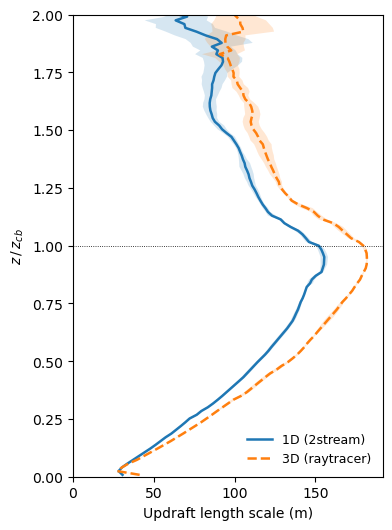

In [14]:
def _integral_length(C: np.ndarray, r: np.ndarray) -> float:
    """∫₀^{r₀} C(r) dr with r₀ = first zero crossing (or first negative bin)."""
    if not np.isfinite(C).any():
        return np.nan
    # First index where C changes sign (zero crossing from positive)
    pos = C > 0
    if not pos[0]:
        return 0.0
    zc = np.where(~pos)[0]
    i0 = int(zc[0]) if zc.size else len(C)
    if i0 < 2: return 0.0
    return float(np.trapezoid(C[:i0], r[:i0]))


def _lst_from(ds):
    t = ds.time.values
    if np.issubdtype(t.dtype, np.datetime64):
        ti = pd.DatetimeIndex(t)
        return ti.hour + ti.minute/60 + ti.second/3600
    return t / 3600.0 + LST_OFFSET


L_profiles, L_sem, C_mean = {}, {}, {}
r_axis = z_axis = None
for rt, reps in ac.items():
    L_list, C_list = [], []
    for ds in reps:
        lst = _lst_from(ds)
        sel = (lst >= LST_LO_E) & (lst <= LST_HI_E)
        if not sel.any(): continue
        Csub  = ds['C'].isel(time=np.where(sel)[0])
        Cmean = Csub.mean('time').values                       # (nz, n_bins)
        C_list.append(Cmean)
        r = ds['r'].values
        L_list.append(np.array(
            [_integral_length(Cmean[iz], r) for iz in range(Cmean.shape[0])]))
    if not L_list: continue
    L_arr = np.stack(L_list)                                   # (nrep, nz)
    L_profiles[rt] = np.nanmean(L_arr, axis=0)
    L_sem[rt]      = np.nanstd(L_arr, axis=0, ddof=1) / np.sqrt(max(1, L_arr.shape[0]))
    C_mean[rt]     = np.nanmean(np.stack(C_list), axis=0)      # (nz, n_bins)
    r_axis = ds['r'].values
    z_axis = ds['z'].values

# z_cb from column cache — used as the y-axis normalisation factor
def _zcb_afternoon(rt):
    COL = Path('/pscratch/sd/m/mpowell/CASS_LES/analysis/cache/couvreux_columns') / EXPT_KEY
    vals = []
    for f in sorted(COL.glob(f'{rt}_rep_*.pkl')):
        with open(f, 'rb') as fh: d = pickle.load(fh)
        v = d['z_cb']['values']; l = d['z_cb']['lst']
        m = (l >= LST_LO_E) & (l <= LST_HI_E)
        if m.sum() >= 20:
            vals.append(np.percentile(v[m], 50))
    return float(np.mean(vals)) if vals else np.nan

z_cb = {rt: _zcb_afternoon(rt) for rt in L_profiles}

# Plot — y-axis is z / z_cb (per-RT normalisation; cloud base at ẑ = 1)
Z_ND_MAX = 2.0
RT_COLOR = {'2stream': 'tab:blue', 'raytracer': 'tab:orange'}

fig, ax_L = plt.subplots(1, 1, figsize=(4, 6))
for rt in L_profiles:
    if not np.isfinite(z_cb[rt]) or z_cb[rt] <= 0: continue
    L, sem = L_profiles[rt], L_sem[rt]
    z_nd   = z_axis / z_cb[rt]
    ax_L.plot(L, z_nd, color=RT_COLOR[rt], lw=1.8,
              ls='-' if rt == '2stream' else '--', label=RT_LABEL[rt])
    ax_L.fill_betweenx(z_nd, L - sem, L + sem,
                       color=RT_COLOR[rt], alpha=0.18, linewidth=0)
ax_L.axhline(1.0, color='k', lw=0.6, ls=':')
ax_L.set_xlabel(r'Updraft length scale (m)')
ax_L.set_ylabel(r'$z\,/\,z_{cb}$')
ax_L.set_ylim(0, Z_ND_MAX); ax_L.set_xlim(left=0)
ax_L.legend(fontsize=9, frameon=False)

plt.show()